# Causal Discovery Analysis


**Reference:** Kumu R package, `issue_causal_analysis.Rmd` 

## Notebook Setup Instructions

### 1. Prerequisites

- **Conda:** Miniconda 
- **Java:** JDK 21+ (Corretto 21 recommended)
- **Editor:** VS Code with the Jupyter extension

### 2. Create the Conda Environment

From the repository root (`pykumu/`):

```bash
conda env create -f env.yml
conda activate pykumu-causal-analysis
python -m ipykernel install --user --name pykumu-causal-analysis --display-name "pykumu-causal-analysis"
```

If `conda` is not recognized in PowerShell, initialize Conda and reopen terminal:

```powershell
& "$env:USERPROFILE\miniconda3\shell\condabin\conda-hook.ps1"
conda init powershell
```

### 2.5 Java Note (Important)

`env.yml` does **not** install Java. This project expects a **system JDK 21** (for example Corretto 21) available through `JAVA_HOME` and `PATH`.

Verify Java in your active shell before running the notebook:

```powershell
$env:JAVA_HOME
java -version
```

If `JAVA_HOME` is empty or Java is not found, install Corretto 21 and set `JAVA_HOME` to the JDK install path.

### 3. Required Files for This Notebook

These files must exist in `causal_analysis_notebook/`:

- `null_variable_dt.csv` (input data)
- `mike_knowledge_box.txt` (domain knowledge)
- `resources/tetrad-current.jar` (Java Tetrad runtime)


## Configuration

Set algorithm parameters and file paths.

In [39]:
# Analysis Parameters
ALGORITHM = "boss"  # Options: "boss" or "fges"

# Input/output paths
DATA_PATH = "null_variable_dt.csv"  # Input CSV (raw or preprocessed format)
KNOWLEDGE_FILE = "mike_knowledge_box.txt"

# Algorithm-specific configs (edit these values directly)
FGES_CONFIG = {
    "n_bootstrap": 50,
    "penalty_discount": 2,
    "sem_bic_rule": 1,
    "structure_prior": 0,
    "singularity_lambda": 0.0,
    "bootstrap_percent_resample_size": 90,
    "bootstrap_seed": 32,
    "bootstrap_add_original": True,
    "bootstrap_with_replacement": True,
    "bootstrap_resampling_ensemble": 1,
    "verbose": False,
    "max_degree": 1000,
    "faithfulness_assumed": True,
    "symmetric_first_step": True,
    "parallelized": False,
}

BOSS_CONFIG = {
    "n_bootstrap": 50,
    "penalty_discount": 2,
    "sem_bic_rule": 1,
    "structure_prior": 0,
    "singularity_lambda": 0.0,
    "bootstrap_percent_resample_size": 100,
    "bootstrap_seed": 32,
    "bootstrap_add_original": True,
    "bootstrap_with_replacement": True,
    "bootstrap_resampling_ensemble": 1,
    "verbose": False,
    "num_starts": 1,
    "use_bes": False,
    "time_lag": 0,
    "use_data_order": True,
    "output_cpdag": True,
}

## Import Libraries

Load required modules for data processing and causal analysis.

In [40]:
import os
import sys
import time

import pandas as pd
import numpy as np

# Ensure local repo code takes precedence over system-installed packages.
_repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

from api.tetrad import initialize_tetrad_jvm
from api.graph import parse_graph, filter_null_edges, pnef_threshold, apply_pnef
from api.data import (
    npn_transform,
    add_time_lag_by_group,
    remove_short_groups,
    make_null_features,
    keep_first_columns,
)
from api.algorithm import run_fges_algorithm, run_boss_algorithm

_jar_path = initialize_tetrad_jvm(repo_root=_repo_root, working_dir=os.getcwd())
print(f"JVM ready with jar: {_jar_path}")

JVM ready with jar: c:\Users\phuon\OneDrive\Documents\GitHub\pykumu\causal_analysis_notebook\resources\tetrad-current.jar


# Feature Engineering


## Formatting Data Types

In order to be loaded in Tetrad, some variables must be transformed from String to Integer due to data type limitations. 

### CVE Data Type

We concatenate the last two digits of the year with the last four digits of the cve_id and convert into an integer. (E.g. 2006 and CVE ID XXX4339 becomes 06339).


In [41]:
# Matches R: dt <- fread(...)
raw_dt = pd.read_csv(DATA_PATH)

# Matches R: dt$cve_id <- as.integer(stri_c(last_two_digits_year, last_four_digits_cve))
if "cve_id" in raw_dt.columns:
    cve_as_str = raw_dt["cve_id"].astype(str)
    cve_id_col = pd.to_numeric(cve_as_str.str.slice(6, 8) + cve_as_str.str.slice(-4), errors="coerce")
else:
    b_cols_present = [c for c in raw_dt.columns if c.startswith("b_")]
    if b_cols_present:
        b_mat = raw_dt[b_cols_present].to_numpy()
        b_idx = b_mat.argmax(axis=1)
        has_signal = b_mat.sum(axis=1) > 0
        cve_id_col = [
            int(b_cols_present[b_idx[r]].replace("b_", "")) if has_signal[r] else r
            for r in range(len(raw_dt))
        ]
    else:
        cve_id_col = range(len(raw_dt))

# Matches R: dt$activity_0 <- ifelse(dt$commit_interval == "",1,0)
#            dt$activity_2 <- ifelse(dt$commit_interval != "",1,0)
if "commit_interval" in raw_dt.columns:
    commit_interval = raw_dt["commit_interval"].fillna("").astype(str)
    activity_0_col = np.where(commit_interval.eq(""), 1, 0)
    activity_2_col = np.where(commit_interval.ne(""), 1, 0)
elif "commit" in raw_dt.columns:
    activity_0_col = np.where(raw_dt["commit"] <= 0, 1, 0)
    activity_2_col = np.where(raw_dt["commit"] > 0, 1, 0)
else:
    activity_0_col = 0
    activity_2_col = 0

# Build new DataFrame via concat to avoid PerformanceWarning on fragmented frame
new_cols = pd.DataFrame({"cve_id": cve_id_col, "activity_0": activity_0_col, "activity_2": activity_2_col})
raw_dt = pd.concat([raw_dt.reset_index(drop=True), new_cols], axis=1)
# If cve_id already existed in raw_dt, drop the original to avoid duplicate
if raw_dt.columns.duplicated().any():
    raw_dt = raw_dt.loc[:, ~raw_dt.columns.duplicated(keep="last")]

### Convert "start" to Unix Timestamp

To use start in causal analysis, we convert it to a unix timestamp. 

In [42]:
# Matches R: dt$start <- as.numeric(dt$start)
if "start_datetime" in raw_dt.columns:
    raw_dt["start"] = pd.to_datetime(raw_dt["start_datetime"], errors="coerce", utc=True)
    raw_dt["start"] = raw_dt["start"].map(lambda x: x.timestamp() if pd.notna(x) else np.nan)
elif "start" in raw_dt.columns:
    if not pd.api.types.is_numeric_dtype(raw_dt["start"]):
        raw_dt["start"] = pd.to_datetime(raw_dt["start"], errors="coerce", utc=True)
        raw_dt["start"] = raw_dt["start"].map(lambda x: x.timestamp() if pd.notna(x) else np.nan)
else:
    raise ValueError("Expected either 'start_datetime' or 'start' column in data")

## Feature Renaming

In [43]:
# Matches R: setnames(x=dt, old=c("start_datetime",...), new=c("start",...))
rename_map = {
    "start_datetime": "start",
    "missing_links": "mis_link",
    "radio_silence": "silence",
    "code_only_devs": "code_dev",
    "code_files": "file",
    "ml_only_devs": "mail_dev",
    "ml_threads": "thread",
    "n_commits": "commit"
}
raw_dt = raw_dt.rename(columns={k: v for k, v in rename_map.items() if k in raw_dt.columns})

# Matches R: dt <- dt[,.(cve_id, activity_0, activity_2, start, org_silo, ...)]
required_cols = [
    "cve_id", "activity_0", "activity_2", "start",
    "org_silo", "mis_link", "silence", "code_dev", "file",
    "mail_dev", "thread", "commit", "churn"
]
for col in required_cols:
    if col not in raw_dt.columns:
        raw_dt[col] = 0

dt = raw_dt[required_cols].copy()

C:\Users\phuon\AppData\Local\Temp\ipykernel_44568\1280099306.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dt[col] = 0


## Missing Data Handling

We decided to remove rows from the dataset for which the mailing list data source is missing (i.e. 2000-2001).

In [44]:
# Matches R: dt$start <- lubridate::ymd_hms(dt$start)
#            dt <- dt[(year(start) < 2000) | (year(start) > 2001)]
if pd.api.types.is_numeric_dtype(dt["start"]):
    start_dt_series = pd.to_datetime(dt["start"], unit='s', utc=True, errors='coerce')
else:
    start_dt_series = pd.to_datetime(dt["start"], errors="coerce", utc=True)

mask = (start_dt_series.dt.year < 2000) | (start_dt_series.dt.year > 2001)
dt = dt[mask].copy()
start_dt_series = start_dt_series[mask]

dt["start"] = start_dt_series.map(lambda x: x.timestamp() if pd.notna(x) else np.nan)

# Matches R: setnafill(dt, cols = colnames(dt), fill = 0)
dt = dt.fillna(0)

## 1-Time Lag Features

In [45]:
# Matches R: add_time_lag function + lag_dt <- dt[order(cve_id,start)][, add_time_lag(.SD), by = c("cve_id")]
lag_feature_cols = [
    "org_silo", "mis_link", "silence", "code_dev", "file",
    "mail_dev", "thread", "commit", "churn"
]

lag_dt = add_time_lag_by_group(
    dt=dt,
    group_col="cve_id",
    time_col="start",
    lag_feature_cols=lag_feature_cols,
    lag_suffix="2",
)

## Remove Short CVEs

We deleted CVEs (their associated rows) with 7 or fewer time periods.

In [46]:
# Matches R: short_cves <- lag_dt[,.(n_rows=.N),by="cve_id"][order(n_rows)][n_rows <= 7]
lag_dt, short_cves = remove_short_groups(lag_dt, group_col="cve_id", min_rows=8)
print(short_cves.to_string(index=False))

Empty DataFrame
Columns: [cve_id, n_rows]
Index: []


## Addressing Determinism and High Intercorrelation Among Features

Due to high correlation, we perform 6 feature deletions (activity_0, activity_2, org_silo, org_silo2):

In [47]:
# Matches R: cor(cor_table) where cor_table includes org_silo through churn2
cor_cols = [c for c in ["org_silo", "mis_link", "silence", "code_dev", "file",
                         "mail_dev", "thread", "commit", "churn",
                         "org_silo2", "mis_link2", "silence2", "code_dev2", "file2",
                         "mail_dev2", "thread2", "commit2", "churn2"]
            if c in lag_dt.columns]
cor_table = lag_dt[cor_cols]
print(cor_table.corr().to_string())

           org_silo  mis_link   silence  code_dev      file  mail_dev    thread    commit     churn  org_silo2  mis_link2  silence2  code_dev2     file2  mail_dev2   thread2   commit2    churn2
org_silo        NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN        NaN        NaN       NaN        NaN       NaN        NaN       NaN       NaN       NaN
mis_link        NaN  1.000000  0.270009  0.651496  0.247679  0.537431  0.523967  0.154506  0.256343        NaN   0.664019  0.109199   0.443325  0.111049   0.437244  0.494828  0.103424  0.091262
silence         NaN  0.270009  1.000000 -0.036930 -0.313726  0.661025  0.576541 -0.223010 -0.310785        NaN   0.247341  0.427409  -0.028962 -0.213310   0.410715  0.406222 -0.150791 -0.159144
code_dev        NaN  0.651496 -0.036930  1.000000  0.452293  0.243087  0.216746  0.366417  0.457572        NaN   0.461090 -0.111121   0.545635  0.350987   0.177286  0.212512  0.349685  0.273356
file            NaN  0.247679 

In [48]:
# Matches R: lag_dt <- lag_dt[,.(cve_id, start, mis_link, ..., churn2)]
lag_dt = lag_dt[["cve_id", "start",
    "mis_link", "silence", "code_dev", "file",
    "mail_dev", "thread", "commit", "churn",
    "mis_link2", "silence2", "code_dev2", "file2",
    "mail_dev2", "thread2", "commit2", "churn2"
]].copy()

# Non-Parametric Transformation

Apply a nonparanormal (NPN-style) transform to numeric feature columns to better approximate Gaussian marginals before causal search, analogous to `huge.npn` in R.

In [49]:
# Matches R: lag_dt <- cbind(lag_dt[,.(cve_id,start)], huge.npn(lag_dt[,3:ncol(lag_dt)]))
lag_dt = npn_transform(lag_dt, protected_cols=("cve_id", "start"))
print("Applied NPN-style transform to", len(lag_dt.columns) - 2, "feature columns.")
lag_dt.head(6)

Applied NPN-style transform to 16 feature columns.


,cve_id,start,mis_link,silence,code_dev,file,mail_dev,thread,commit,churn,mis_link2,silence2,code_dev2,file2,mail_dev2,thread2,commit2,churn2
0,62937,1.015183e+09,0.171517,1.391586,-0.799050,0.184322,0.880501,0.488813,0.536430,0.310845,0.508438,1.777876,0.198497,0.859416,1.933164,1.690522,0.755013,1.271234
1,62937,1.022959e+09,0.543113,1.767764,0.212442,0.827191,1.961130,1.757830,0.740082,1.224336,1.021675,0.527959,0.638818,1.176832,1.421957,1.365109,0.700935,1.490158
2,62937,1.030735e+09,1.075363,0.544940,0.683251,1.127868,1.462059,1.397837,0.686239,1.419076,0.757810,-0.048334,1.004566,0.949547,1.550182,1.890708,0.700935,-0.156879
3,62937,1.038511e+09,0.798689,-0.028100,1.070227,0.914679,1.599164,1.990720,0.686239,-0.171783,-0.262414,0.609464,-0.263229,0.455640,1.342137,0.963655,0.548293,0.208147
4,62937,1.046287e+09,-0.234249,0.625670,-0.268670,0.434764,1.377888,0.999361,0.536430,0.191003,-0.706990,-0.702950,-0.263229,-1.322995,-0.459139,-0.280122,-0.808116,-2.026238
5,62937,1.054063e+09,-0.669060,-0.670375,-0.268670,-1.327418,-0.426122,-0.249661,-0.812492,-2.026238,0.143335,0.028626,-0.263229,-0.173383,0.387329,0.451566,-0.541896,-1.465124


## Binarized CVE Indicators

To represent the CVE Ids, we utilize indicator features. For every CVE ID, a new column is added to the table which can take values 0 or 1. The value is 1 if the row is associated to that CVE ID, or 0 otherwise.

We can then remove the `cve_id` column, as the binary features represent the same information, and add the remaining columns to the analysis table:

In [50]:
cve_binarized = pd.get_dummies(
    lag_dt["cve_id"].astype("Int64").astype(str),
    prefix="b",
    dtype=int
)

# Matches R: head(cbind(cve_id=lag_dt$cve_id,binarize_cve_id))
binarize_preview = pd.concat([
    lag_dt[["cve_id"]].reset_index(drop=True),
    cve_binarized.reset_index(drop=True)
], axis=1)
print(binarize_preview.head(6).to_string())

   cve_id  b_100433  b_100740  b_100742  b_102939  b_103864  b_104180  b_113207  b_114109  b_114576  b_114577  b_114619  b_120027  b_120884  b_122110  b_122333  b_130166  b_134353  b_136450  b_140076  b_140160  b_140195  b_140221  b_140224  b_142970  b_143470  b_143505  b_143506  b_143507  b_143508  b_143509  b_143510  b_143511  b_143513  b_143567  b_143568  b_143569  b_143570  b_143571  b_143572  b_148275  b_150204  b_150205  b_150206  b_150207  b_150208  b_150209  b_150285  b_150286  b_150287  b_150288  b_150289  b_150290  b_150291  b_151787  b_151788  b_151789  b_151790  b_151791  b_151793  b_151794  b_160701  b_160702  b_160705  b_160797  b_160798  b_160799  b_162105  b_162106  b_162107  b_162108  b_162109  b_162176  b_162178  b_162179  b_162180  b_162181  b_162182  b_166302  b_166303  b_166304  b_167053  b_173731  b_173733  b_180732  b_180734  b_180735  b_180737  b_180739  b_191547  b_191549  b_201967  b_62937  b_62940  b_63738  b_64339  b_80891  b_81672  b_93245
0   62937        

In [51]:
# Matches R: lag_dt <- lag_dt[,.(start, mis_link, ..., churn2)]
#            binarized_lag_dt <- cbind(lag_dt, binarize_cve_id[,(2:ncol),with=FALSE])
binarized_lag_dt = pd.concat([
    lag_dt.drop(columns=["cve_id"]).reset_index(drop=True),
    cve_binarized.reset_index(drop=True)
], axis=1)

## Add Null Features

An example of the randomization only showing the silence and nv-silence is shown below. In practice, for every column in `binarized_lag_dt`, we generate a replica column prefixed by `nv-`, including the binary features (which are then prefixed as `nv-b_`), but the replica columns have their values shuffled across the rows, hence the null (random) naming to them.

In [52]:
# Matches R: nv_lag_dt <- apply shuffled null copies and cbind
nv_lag_dt = make_null_features(binarized_lag_dt, seed=32, prefix="nv-")

# Matches R: head(nv_lag_dt[,.(silence,`nv-silence`)])
print(nv_lag_dt[["silence", "nv-silence"]].head(6).to_string())

    silence  nv-silence
0  1.391586   -0.349669
1  1.767764   -0.934406
2  0.544940    0.544940
3 -0.028100   -0.753617
4  0.625670   -0.286135
5 -0.670375    0.440544


## Keep only 5 null indicator features

Introducing a null feature for all variables and features leads to too many features being introduced for causal search, causing heap memory errors in Tetrad. We preserve only a few of the nv binary indicator variables, as they lead to variable explosion and their pattern is easy to randomize. Position 138 includes all variables as null variables, plus five binary indicators as null variables. We consider this loss of null binary indicator features reasonable, as the randomization of a few blocks of values 1 or 0 will generally be equivalent. This in turn, allow us to perform more causal search runs, which we deem a fair trade-off.

In [53]:
# Matches R: nv_lag_dt <- nv_lag_dt[,1:138]
nv_lag_dt = keep_first_columns(nv_lag_dt, max_cols=138)

In [54]:
# Matches R: nv_lag_dt_path <- "/tmp/null_variable_dt.csv"; fwrite(nv_lag_dt, nv_lag_dt_path)
os.makedirs("processed_data", exist_ok=True)
nv_lag_dt.to_csv("processed_data/null_variable_processed_dt.csv", index=False)
binarized_lag_dt.to_csv("processed_data/binarized_variable_dt.csv", index=False)

# Use processed data in-memory for the rest of the notebook
data = nv_lag_dt.astype({col: "float64" for col in nv_lag_dt.columns})

# FGES Null Variable Search

Executes causal discovery with bootstrapping over the null-variable dataset.

In [55]:
# Matches R: data_io + algorithm_boss/fges + score_sem_bic + bootstrapping + tetrad()
if ALGORITHM == "boss":
    elapsed, graph, null_graph_json = run_boss_algorithm(data, knowledge_file=None, **BOSS_CONFIG)
elif ALGORITHM == "fges":
    elapsed, graph, null_graph_json = run_fges_algorithm(data, knowledge_file=None, **FGES_CONFIG)
else:
    raise ValueError("ALGORITHM must be either 'boss' or 'fges'")

print(f"Discovered: {graph.getNumNodes()} nodes, {graph.getNumEdges()} edges")
print(f"Elapsed: {elapsed:.1f}s")

Discovered: 138 nodes, 97 edges
Elapsed: 37.6s


---

# Deriving the 1 PNEF Threshold

In our causal search above, we introduced null features over multiple bootstrap runs to observe how often our causal search forms random edges (i.e. between our features and null features). We will use this information to derive a threshold, **1PNEF** (1st Percentile NoEdge Frequency), we can use in our final causal search.

## Graph Examination

We parse the Tetrad JSON graph output into tabular format: nodes, edgeset, and edge type probabilities.

The **edgeset** table contains the ensemble edge for each node pair. Because we performed multiple bootstrap runs, the probabilities represent the ensemble of all edges formed on each execution.

The **edge_type_probabilities** table shows the counts of each type of edge formed on each subgraph across all bootstrap runs.

In [56]:
# Matches R: graph <- parse_graph(filepath)
null_graph = parse_graph(null_graph_json)

# Matches R: head(graph[["nodes"]])
print(null_graph['nodes'].head(6).to_string())

# Matches R: head(graph[["edgeset"]])
print(f"\n")
print(null_graph['edgeset'].head(6).to_string())

# Matches R: head(graph[["edge_type_probabilities"]])
print(f"\n")
print(null_graph['edge_type_probabilities'].head(6).to_string())

  node_name
0  b_100433
1  b_100740
2  b_100742
3  b_102939
4  b_103864
5  b_104180


  node1_name node2_name endpoint1 endpoint2   bold  highlighted properties  probability
0      start   b_160705      TAIL     ARROW  False        False      pd;nl     0.686275
1   mail_dev    silence      TAIL     ARROW  False        False        NaN     1.000000
2    silence   silence2      TAIL     ARROW  False        False      dd;nl     0.784314
3      start    commit2      TAIL     ARROW  False        False      dd;nl     0.843137
4    thread2     churn2      TAIL     ARROW  False        False      dd;nl     0.882353
5   mis_link   silence2      TAIL     ARROW  False        False      dd;nl     0.843137


  node1_name node2_name edge_type properties  probability
0      start   b_160705        ta      pd;nl     0.588235
1      start   b_160705       nil        NaN     0.313725
2      start   b_160705        at      pd;pl     0.098039
3   mail_dev    silence        ta        NaN     0.509804
4   ma

## Deriving 1 PNEF

Our interest is to derive a threshold for the final causal search, using the information from this bootstrapped null feature causal search. By definition, edges formed between actual variables and random (null) features represent random edges.

We:
1. Subset the edgeset to contain only edges where at least one node is a null variable (nv-*)
2. Derive a `no_edge` probability by subtracting the probability from 1
3. Identify the 1st percentile value of the no_edge probability → the **1PNEF threshold**

This threshold tells us: given entirely random variables, causal links were formed between them up to X% of the time. In our final search, we only keep causal links that formed **more** than X% of the time.

In [57]:
# Matches R: subset to null-variable edges and derive 1PNEF
nv_edges = filter_null_edges(null_graph['edgeset'], null_prefix='nv-')
print(nv_edges.head(6).to_string())

pnef_1 = pnef_threshold(nv_edges, quantile=0.01)
print(f"\n1%\n{pnef_1}")

   node1_name   node2_name endpoint1 endpoint2   bold  highlighted properties  probability
68   b_160798  nv-b_100742      TAIL     ARROW  False        False      pd;pl     0.627451

1%
0.37254901960784315


---

# Non-Null Causal Search

With the threshold defined, we now proceed to the final causal search, which **does not include null features**. In this non-null feature causal search, we also specify domain knowledge to prohibit causal links that don't make sense temporally (e.g. features at 1-time-lag cannot cause features in the present).

## Domain Knowledge Causal Search without Null Variables

Remove null variable columns (nv-*) from the dataset, keeping only the original features and binary CVE indicators.

In [58]:
nv_cols       = [col for col in data.columns if col.startswith('nv-')]
non_null_data = data.drop(columns=nv_cols)
non_null_data.to_csv("processed_data/binarized_variable_dt.csv", index=False)
print(f"Non-null dataset: {non_null_data.shape[0]} rows × {non_null_data.shape[1]} columns")
print(f"Saved to: processed_data/binarized_variable_dt.csv")

Non-null dataset: 4772 rows × 115 columns
Saved to: processed_data/binarized_variable_dt.csv


## Causal Search

Run the causal search on the non-null dataset with domain knowledge constraints. This search uses the same algorithm and bootstrap settings, but on the dataset **without** null features and **with** temporal knowledge constraints.

In [59]:
# Matches R: data_io + knowledge_flags + algorithm_boss/fges + score_sem_bic + bootstrapping + tetrad()
knowledge_path = KNOWLEDGE_FILE if os.path.exists(KNOWLEDGE_FILE) else None

if ALGORITHM == "boss":
    elapsed, domain_graph_obj, domain_graph_json = run_boss_algorithm(
        non_null_data,
        knowledge_file=knowledge_path,
        **BOSS_CONFIG,
    )
elif ALGORITHM == "fges":
    elapsed, domain_graph_obj, domain_graph_json = run_fges_algorithm(
        non_null_data,
        knowledge_file=knowledge_path,
        **FGES_CONFIG,
    )
else:
    raise ValueError("ALGORITHM must be either 'boss' or 'fges'")

if knowledge_path:
    print(f"Knowledge loaded from: {knowledge_path}")

print(f"Discovered: {domain_graph_obj.getNumNodes()} nodes, {domain_graph_obj.getNumEdges()} edges")
print(f"Elapsed: {elapsed:.1f}s")

Knowledge loaded from: mike_knowledge_box.txt
Discovered: 115 nodes, 97 edges
Elapsed: 22.8s


## Graph Examination

Parse the domain knowledge causal search JSON output into nodes, edgeset, and edge type probabilities.

In [60]:
# Parse the domain search JSON output
domain_graph = parse_graph(domain_graph_json)

print(f"Domain search nodes: {len(domain_graph['nodes'])}")
print(f"Domain search edges: {len(domain_graph['edgeset'])}")
print(f"\nEdgeset sample:")
domain_graph['edgeset'].head()


Domain search nodes: 115
Domain search edges: 97

Edgeset sample:


,node1_name,node2_name,endpoint1,endpoint2,bold,highlighted,properties,probability
0,start,b_160705,TAIL,ARROW,False,False,pd;nl,0.686275
1,mail_dev,silence,TAIL,ARROW,False,False,NaN,1.000000
2,silence,silence2,TAIL,ARROW,False,False,dd;nl,0.764706
3,start,commit2,TAIL,ARROW,False,False,dd;nl,0.882353
4,mis_link,mail_dev,TAIL,ARROW,False,False,dd;nl,0.627451


---

# Applying 1PNEF Threshold

## Applying 1PNEF Threshold

Edges which may have been formed at random are filtered here. We apply the 1PNEF threshold derived from the null variable search to the domain knowledge search results. Only edges whose `no_edge` probability is less than or equal to the 1PNEF threshold are kept.

In [61]:
# Applying 1PNEF Threshold (R-equivalent explicit steps)
edges_1pnef = apply_pnef(domain_graph['edgeset'], pnef_value=pnef_1)

print(f"\nFiltered edges (1PNEF trimmed): {len(edges_1pnef)}")
edges_1pnef.head(20)


Filtered edges (1PNEF trimmed): 92


,node1_name,node2_name,endpoint1,endpoint2,bold,highlighted,properties,probability,no_edge
0,start,b_160705,TAIL,ARROW,False,False,pd;nl,0.686275,0.313725
1,mail_dev,silence,TAIL,ARROW,False,False,NaN,1.000000,0.000000
2,silence,silence2,TAIL,ARROW,False,False,dd;nl,0.764706,0.235294
3,start,commit2,TAIL,ARROW,False,False,dd;nl,0.882353,0.117647
4,mis_link,mail_dev,TAIL,ARROW,False,False,dd;nl,0.627451,0.372549
5,thread2,churn2,TAIL,ARROW,False,False,dd;nl,0.882353,0.117647
6,mis_link,silence2,TAIL,ARROW,False,False,dd;nl,0.843137,0.156863
7,mis_link2,mail_dev2,TAIL,ARROW,False,False,pd;nl,0.862745,0.137255
8,mail_dev,churn2,TAIL,ARROW,False,False,dd;pl,0.686275,0.313725
9,silence,commit2,TAIL,ARROW,False,False,dd;nl,0.882353,0.117647


In [62]:
# Save the 1PNEF-filtered edges
output_dir = "boss_domain_results" if ALGORITHM == "boss" else "fges_domain_results"
os.makedirs(output_dir, exist_ok=True)
edges_1pnef.to_csv(f"{output_dir}/edges_1pnef.csv", index=False)
print(f"✓ Saved filtered edges to {output_dir}/edges_1pnef.csv")

✓ Saved filtered edges to boss_domain_results/edges_1pnef.csv


---

# Results

With the final causal graph trimmed, we can now inspect it to draw conclusions. Causal graphs may form cycles and have undirected edges.

Visualizations are rendered using **pydot** and **Graphviz**.

## Full Causal Graph 1-PNEF Trimmed

Static visualization of the full causal graph after applying the 1PNEF threshold.

Edge colors:
- **Black**: Directed edges (causal relationship)
- **Red**: Undirected edges (TAIL-TAIL, association without determined direction)


Full graph (92 edges) saved to: boss_domain_results/causal_graph_full.png


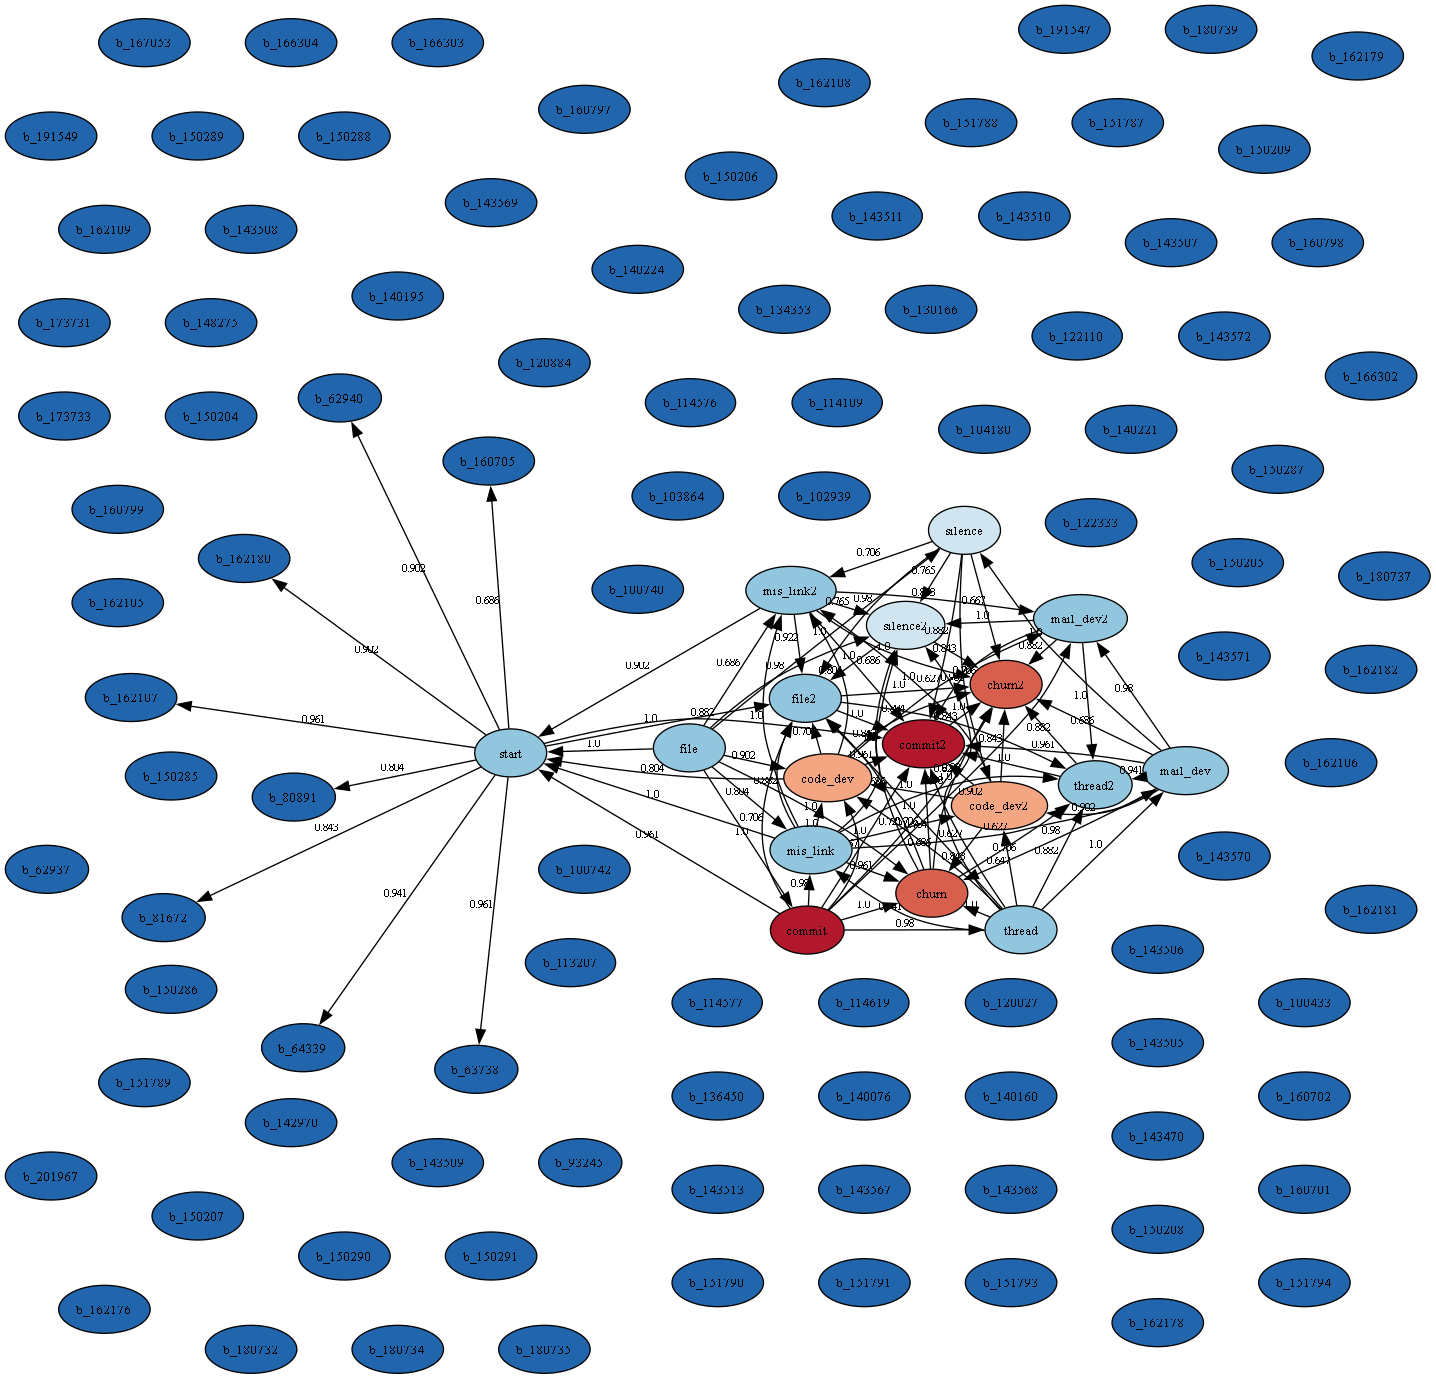

In [63]:
import os

# Add Graphviz bin to PATH so pydot can find the "dot" executable
_GRAPHVIZ_BIN = 'C:\\Program Files\\Graphviz\\bin'
if _GRAPHVIZ_BIN not in os.environ.get("PATH", ""):
    os.environ["PATH"] = _GRAPHVIZ_BIN + os.pathsep + os.environ.get("PATH", "")

import pydot
from IPython.display import Image, display

# Color scheme matching R colorBlindness::Blue2DarkRed12Steps
COLORBLIND_PALETTE = {
    "b_":       "#2166AC",  # [1]  Dark blue  — binary indicators
    "silence":  "#D1E5F0",  # [5]  Pale blue  — silence/silence2
    "mis_link": "#92C5DE",  # [3]  Light blue — mis_link
    "code_dev": "#F4A582",  # [7]  Pale red   — code_dev
    "churn":    "#D6604D",  # [8]  Light red  — churn
    "commit":   "#B2182B",  # [9]  Dark red   — commit
    "default":  "#92C5DE",  # [3]  Default: light blue
}

def _node_color(name):
    for key, color in COLORBLIND_PALETTE.items():
        if key != "default" and key in name:
            return color
    return COLORBLIND_PALETTE["default"]

# Prepare edges — matches R: edges$color <- ...
viz_edges = edges_1pnef.copy()
viz_edges["color"] = "black"
viz_edges.loc[
    (viz_edges["endpoint1"] == "TAIL") & (viz_edges["endpoint2"] == "TAIL"),
    "color"
] = "red"

# Build pydot directed graph — matches R: igraph::graph_from_data_frame + visIgraph
dot_full = pydot.Dot(graph_type="digraph",
                     bgcolor="white", fontsize=10)
dot_full.set_graph_defaults(overlap="false", splines="true")

# Collect all node names (nodes without edges are still included)
all_nodes = set(viz_edges["node1_name"]).union(viz_edges["node2_name"])
all_nodes.update(domain_graph["nodes"]["node_name"].tolist())

for name in sorted(all_nodes):
    dot_full.add_node(pydot.Node(
        name,
        style="filled",
        fillcolor=_node_color(name),
        fontsize=10,
        shape="ellipse"
    ))

for _, row in viz_edges.iterrows():
    # Determine arrow directions from endpoint types
    arrowhead = "normal" if row["endpoint2"] == "ARROW" else "none"
    arrowtail = "normal" if row["endpoint1"] == "ARROW" else "none"
    dot_full.add_edge(pydot.Edge(
        row["node1_name"], row["node2_name"],
        color=row["color"],
        label=str(round(row["probability"], 3)),
        fontsize=8,
        arrowhead=arrowhead,
        arrowtail=arrowtail,
        dir="both"
    ))

# Render and display
full_graph_path = f"{output_dir}/causal_graph_full.png"
dot_full.write_png(full_graph_path, prog="sfdp")
print(f"Full graph ({len(viz_edges)} edges) saved to: {full_graph_path}")
display(Image(full_graph_path))


## Sub-Graphs of Effort Variables and Parents

Focus on key effort variables and their neighboring causal structure. This sub-graph includes only edges where both endpoints are nodes of interest (effort-related variables), matching the R filter `edges[from %in% nodes_of_interest & to %in% nodes_of_interest]`.


Sub-graph: 10 nodes, 31 edges
Sub-graph saved to: boss_domain_results/causal_graph_subgraph.png


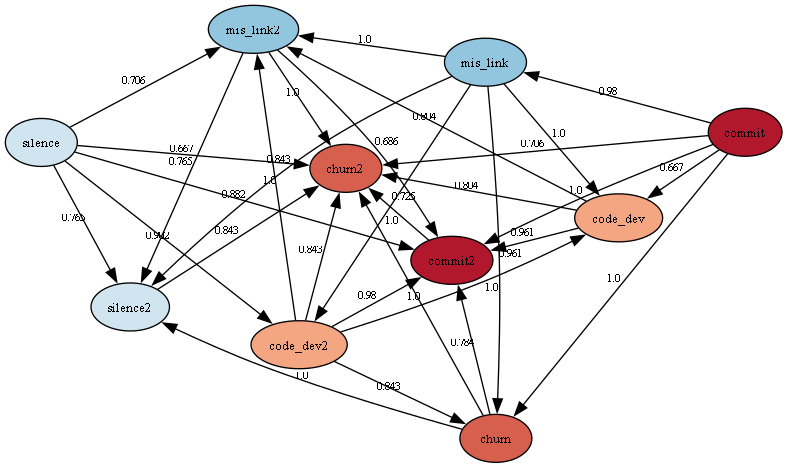

In [64]:
# Nodes of interest — matches R: nodes_of_interest
NODES_OF_INTEREST = [
    "silence",  "silence2",
    "mis_link", "mis_link2",
    "code_dev", "code_dev2",
    "churn",    "churn2",
    "commit",   "commit2",
]

# Filter edges — matches R: edges_n <- copy(edges[from %in% ... & to %in% ...])
sub_edges = viz_edges[
    viz_edges["node1_name"].isin(NODES_OF_INTEREST) &
    viz_edges["node2_name"].isin(NODES_OF_INTEREST)
].copy()

if len(sub_edges) == 0:
    print("No edges found between the nodes of interest.")
else:
    sub_nodes = sorted(set(sub_edges["node1_name"]).union(sub_edges["node2_name"]))
    print(f"Sub-graph: {len(sub_nodes)} nodes, {len(sub_edges)} edges")

    dot_sub = pydot.Dot(graph_type="digraph", rankdir="LR",
                        bgcolor="white", fontsize=10)
    dot_sub.set_graph_defaults(overlap="false", splines="true")

    for name in sub_nodes:
        dot_sub.add_node(pydot.Node(
            name,
            style="filled",
            fillcolor=_node_color(name),
            fontsize=10,
            shape="ellipse"
        ))

    for _, row in sub_edges.iterrows():
        arrowhead = "normal" if row["endpoint2"] == "ARROW" else "none"
        arrowtail = "normal" if row["endpoint1"] == "ARROW" else "none"
        dot_sub.add_edge(pydot.Edge(
            row["node1_name"], row["node2_name"],
            color=row["color"],
            label=str(round(row["probability"], 3)),
            fontsize=8,
            arrowhead=arrowhead,
            arrowtail=arrowtail,
            dir="both"
        ))

    sub_graph_path = f"{output_dir}/causal_graph_subgraph.png"
    dot_sub.write_png(sub_graph_path, prog="sfdp")
    print(f"Sub-graph saved to: {sub_graph_path}")
    display(Image(sub_graph_path))


## Cycle Detection

Check if the causal graph contains any cycles. Cycles indicate feedback loops in the causal structure. Matches R: `find_cycles(g)`.


In [65]:
import networkx as nx

# Build directed graph from directed (non-TAIL-TAIL) edges — matches R: find_cycles(g)
G = nx.DiGraph()
directed_edges = viz_edges[viz_edges["color"] == "black"]
for _, row in directed_edges.iterrows():
    G.add_edge(row["node1_name"], row["node2_name"])

cycles = list(nx.simple_cycles(G))

if not cycles:
    print("No cycles detected in the graph.")
else:
    print(f"Found {len(cycles)} cycle(s):")
    for i, cycle in enumerate(cycles, 1):
        cycle_str = " -> ".join(cycle) + f" -> {cycle[0]}"
        print(f"  Cycle {i} (length {len(cycle)}): {cycle_str}")


No cycles detected in the graph.
